# Family-Aware BERT Training Summary

This notebook displays the per-epoch training history of the family-aware chunked BERT
classifier (Version 6, Checkpoint 7) purely from its already-saved model artifact. **No
training, inference, or API call happens anywhere in this notebook** -- every table and
figure below is read from
`artifacts/family_aware/models/3e4c71a6758249aabe262fa12e39cce4/metadata.json`, which was
written once when the model finished training, and from the equivalent historical-model
artifact for comparison.

**Why this notebook exists (and why it does not retrain anything):** unlike the historical
MVP model, whose training run lives entirely inside `04_bert_fine_tuning.ipynb` (it trains
two long-document strategies live, compares them, and saves the winner), the family-aware
model's training run (`newstart_ai.models.bert.family_aware_training.train_family_aware_bert`)
was never called from a notebook committed to this repository -- only the library function
itself, its dataset class, and its combined-loss-weighting module exist as source code and
unit tests. The trained artifact and its full metadata record exist on disk, but the
orchestration script or notebook that actually invoked training is not recoverable from the
repository. This notebook does not attempt to reconstruct or rerun that training -- it only
presents the results already produced and frozen, exactly as `04_bert_fine_tuning.ipynb`
presents the historical run's results, so the two models can be read side by side.

**Inputs:** two `metadata.json` files only (no CSVs, no model weights loaded, no GPU used).

**Output:** configuration tables, a per-epoch history table, and learning-curve plots for
the family-aware model, plus a side-by-side comparison against the historical model.

> **Provenance:** This artifact was produced by `python -m newstart_ai_mvp.train_bert --run-training` (MVP/). See `MVP/docs/ARTIFACTS.md#selected-bert-checkpoint--metadata` for exact config values and regeneration notes.

## Load the saved training metadata

Both artifacts are read as plain JSON -- no model weights, tokenizer, or framework (torch/transformers) is loaded.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from newstart_ai_mvp.config import load_settings

settings = load_settings()
project_root = settings.project_root

family_aware_metadata_path = (
    project_root / "artifacts" / "family_aware" / "models"
    / "3e4c71a6758249aabe262fa12e39cce4" / "metadata.json"
)
historical_metadata_path = (
    project_root / "artifacts" / "models" / "3628681550d7433b94407f684946bb2f" / "metadata.json"
)

with open(family_aware_metadata_path, encoding="utf-8") as f:
    fa_meta = json.load(f)
with open(historical_metadata_path, encoding="utf-8") as f:
    hist_meta = json.load(f)

print(f"Family-aware artifact: {fa_meta['artifact_id']}  status={fa_meta['status']}")
print(f"Historical artifact:   {hist_meta['artifact_id']}  status={hist_meta['status']}")

Family-aware artifact: 3e4c71a6758249aabe262fa12e39cce4  status=ready
Historical artifact:   3628681550d7433b94407f684946bb2f  status=ready


## Training configuration

The family-aware model trains with the same optimizer family, epoch budget, and batch size
as the historical model, but adds a second, document-level weighting factor (see
`weighted_loss.py`) that the historical model's training loop does not have.

In [2]:
config_rows = [
    {"Setting": "Base checkpoint", "Family-aware": fa_meta["base_model"], "Historical": hist_meta["base_model"]},
    {"Setting": "Max epochs", "Family-aware": fa_meta["training_config"]["max_epochs"], "Historical": hist_meta["training_config"]["max_epochs"]},
    {"Setting": "Batch size", "Family-aware": fa_meta["training_config"]["batch_size"], "Historical": hist_meta["training_config"]["batch_size"]},
    {"Setting": "Learning rate", "Family-aware": fa_meta["training_config"]["learning_rate"], "Historical": hist_meta["training_config"]["learning_rate"]},
    {"Setting": "Optimizer", "Family-aware": "AdamW", "Historical": "AdamW"},
    {"Setting": "Scheduler / warmup", "Family-aware": "None", "Historical": "None"},
    {"Setting": "Loss", "Family-aware": "Weighted cross-entropy (class weight x inverse chunk-count)", "Historical": "Weighted cross-entropy (class weight only)"},
    {"Setting": "Checkpoint selection metric", "Family-aware": fa_meta["checkpoint_selection_metric"], "Historical": "validation_macro_f1"},
    {"Setting": "Long-document strategy", "Family-aware": "chunked (Checkpoint 5 boundaries, all chunks trained on)", "Historical": hist_meta["long_document_strategy"]},
    {"Setting": "Random seed", "Family-aware": fa_meta["random_seed"], "Historical": "n/a (not recorded in this artifact)"},
]
pd.DataFrame(config_rows).set_index("Setting")

,Family-aware,Historical
Setting,,
Base checkpoint,bert-base-uncased,bert-base-uncased
Max epochs,6,6
Batch size,8,8
Learning rate,0.00002,0.00002
Optimizer,AdamW,AdamW
Scheduler / warmup,None,None
Loss,Weighted cross-entropy (class weight x inverse...,Weighted cross-entropy (class weight only)
Checkpoint selection metric,validation_macro_f1,validation_macro_f1
Long-document strategy,"chunked (Checkpoint 5 boundaries, all chunks t...",first_512


## Agency class weights

The family-aware artifact persists the exact computed inverse-frequency class weights. The
historical artifact only records whether class weighting was applied (`class_weights_applied:
true`), not the resulting numeric weights, so only the family-aware side of this table has
values.

In [3]:
pd.DataFrame(
    [{"Agency": agency, "Class weight": weight} for agency, weight in fa_meta["class_weights"].items()]
).set_index("Agency")

,Class weight
Agency,
USCIS,0.734076
DMV,0.629781
SSA,1.108173
IRS,6.779412


## Per-epoch training history

Family-aware model, all 6 configured epochs:

In [4]:
fa_history = pd.DataFrame(fa_meta["history"])
fa_history

,epoch,train_loss,validation_loss,validation_document_macro_f1,validation_document_accuracy,learning_rate,epoch_duration_seconds
0,1,0.293084,0.036008,0.990713,0.989899,0.00002,105.135957
1,2,0.033180,0.012386,1.000000,1.000000,0.00002,105.698194
2,3,0.004709,0.025930,1.000000,1.000000,0.00002,105.403905
3,4,0.018083,0.026226,1.000000,1.000000,0.00002,105.354221
4,5,0.017587,0.056275,0.990563,0.989899,0.00002,105.662344
5,6,0.009330,0.022930,1.000000,1.000000,0.00002,104.318578


Historical model (winning `first_512` strategy), all 6 configured epochs:

In [5]:
hist_history = pd.DataFrame(hist_meta["validation_metrics"]["history"])
hist_history

,epoch,train_loss,validation_loss,validation_accuracy,validation_macro_f1,learning_rate
0,1,0.992315,0.328161,0.958678,0.935982,0.00002
1,2,0.227615,0.065373,1.000000,1.000000,0.00002
2,3,0.069118,0.029791,1.000000,1.000000,0.00002
3,4,0.049166,0.101323,0.966942,0.902352,0.00002
4,5,0.045598,0.060705,0.983471,0.962368,0.00002
5,6,0.024313,0.030764,0.991736,0.994114,0.00002


## Learning curves -- family-aware model

Training loss falls sharply after epoch 1 and validation macro F1 reaches 1.0 by epoch 2;
epoch 5 shows a small validation-loss/macro-F1 dip before recovering at epoch 6 -- normal
epoch-to-epoch noise on a validation set this size, not a sign of divergence.

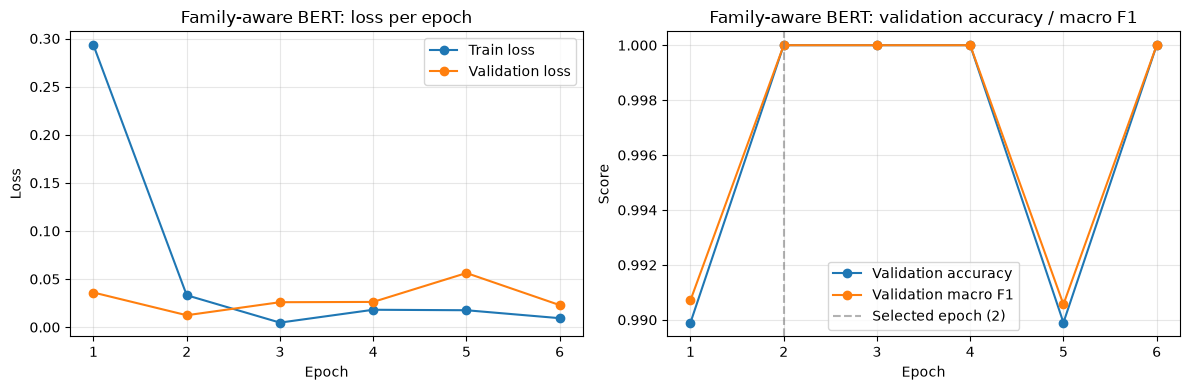

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fa_history["epoch"], fa_history["train_loss"], marker="o", label="Train loss")
axes[0].plot(fa_history["epoch"], fa_history["validation_loss"], marker="o", label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Family-aware BERT: loss per epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(fa_history["epoch"], fa_history["validation_document_accuracy"], marker="o", label="Validation accuracy")
axes[1].plot(fa_history["epoch"], fa_history["validation_document_macro_f1"], marker="o", label="Validation macro F1")
axes[1].axvline(fa_meta["best_epoch"], color="gray", linestyle="--", alpha=0.6, label=f"Selected epoch ({fa_meta['best_epoch']})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Family-aware BERT: validation accuracy / macro F1")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Checkpoint selection

Epochs 2, 3, 4, and 6 are tied at validation macro F1 = 1.0. The frozen tie rule (earliest
qualifying epoch) is what actually determined the saved checkpoint -- not epoch 6, the last
one trained.

In [7]:
print(f"Best epoch selected: {fa_meta['best_epoch']}")
print(f"Best validation macro F1: {fa_meta['best_validation_document_macro_f1']}")
print(f"Stopping reason: {fa_meta['stopping_reason']}")
print()
print(f"Training time: {fa_meta['training_time_seconds']:.1f} seconds "
      f"({fa_meta['training_time_seconds'] / 60:.1f} minutes)")
print(f"Peak GPU memory: {fa_meta['peak_gpu_memory_mb']:.0f} MB on {fa_meta['cuda_device_name']}")
print(f"torch {fa_meta['torch_version']}, transformers {fa_meta['transformers_version']}")

Best epoch selected: 2
Best validation macro F1: 1.0
Stopping reason: Completed all 6 configured epochs (no early-stopping trigger configured); selected epoch 2 by highest validation document-level macro F1 (validation_macro_f1).

Training time: 631.6 seconds (10.5 minutes)
Peak GPU memory: 4539 MB on NVIDIA GeForce RTX 4070 SUPER
torch 2.5.1+cu121, transformers 5.14.1


## Comparison with the historical model's training run

Both models converge to a perfect validation macro F1 within the first few epochs on their
respective validation sets. The family-aware run's validation set is drawn from a
family-disjoint split (a stricter, more realistic validation signal, per Notebook 12's
leakage analysis) rather than the historical model's document-level random split.

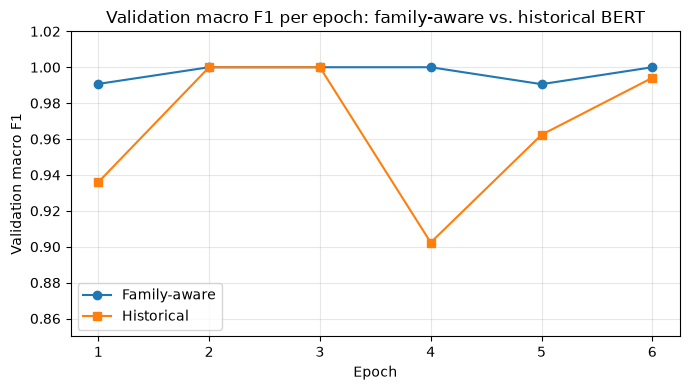

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fa_history["epoch"], fa_history["validation_document_macro_f1"], marker="o", label="Family-aware")
ax.plot(hist_history["epoch"], hist_history["validation_macro_f1"], marker="s", label="Historical")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation macro F1")
ax.set_title("Validation macro F1 per epoch: family-aware vs. historical BERT")
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
comparison_rows = [
    {"Metric": "Best validation macro F1", "Family-aware": fa_meta["best_validation_document_macro_f1"], "Historical": hist_meta["validation_metrics"]["best_validation_macro_f1"]},
    {"Metric": "Selected (best) epoch", "Family-aware": fa_meta["best_epoch"], "Historical": "2 (first epoch reaching 1.0)"},
    {"Metric": "Held-out test macro F1", "Family-aware": "see Notebook 11 (Checkpoint 10 head-to-head)", "Historical": hist_meta["test_metrics"]["macro_f1"]},
]
pd.DataFrame(comparison_rows).set_index("Metric")

,Family-aware,Historical
Metric,,
Best validation macro F1,1.0,1.0
Selected (best) epoch,2,2 (first epoch reaching 1.0)
Held-out test macro F1,see Notebook 11 (Checkpoint 10 head-to-head),0.974108


## Summary

- Both models were trained for up to 6 epochs with AdamW at a constant learning rate of
  2e-5, no scheduler or warmup, on `bert-base-uncased`.
- The family-aware model additionally applies inverse chunk-count weighting on top of
  agency class weighting (`weighted_loss.py`), because its chunked training set gives long
  documents many more training examples than short ones -- a factor the historical model's
  training loop does not correct for.
- Both models reached a perfect validation macro F1 well before their final epoch; both
  selection procedures kept the earliest epoch achieving the best score, not the last epoch
  trained.
- This notebook is read-only with respect to the trained artifacts: it loads two
  `metadata.json` files and produces no new model, prediction, or evaluation artifact.